# fp16 loses your small gradients and bf16 loses your small updates

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## Three layouts, four limits each

In [1]:
import numpy as np

def limits(e_bits, m_bits):                       # IEEE-style layout
    bias = 2 ** (e_bits - 1) - 1
    return ((2 - 2.0 ** -m_bits) * 2.0 ** bias,   # largest finite
            2.0 ** (1 - bias),                    # smallest normal
            2.0 ** (1 - bias - m_bits),           # smallest subnormal
            2.0 ** -m_bits)                       # machine epsilon

for name, e, m in (("fp16", 5, 10), ("bf16", 8, 7), ("fp32", 8, 23)):
    big, norm, sub, eps = limits(e, m)
    print(f"{name}: max {big:.5g}  min normal {norm:.2e}  "
          f"min subnormal {sub:.1e}  eps {eps:.2e}")

rng = np.random.default_rng(0)                    # log-normal |gradients|
g = np.exp(rng.normal(np.log(1e-7), 3.0, 1_000_000)).astype(np.float32)
tiny = np.finfo(np.float16).tiny                  # 2^-14, smallest normal
for k in (0, 8, 16, 20, 24):
    with np.errstate(over="ignore"):
        h = (g * np.float32(2.0 ** k)).astype(np.float16)
    zero, inf = np.mean(h == 0), np.mean(np.isinf(h))
    sub = np.mean((h > 0) & (h < tiny))
    print(f"S = 2^{k:<2d}  zero {zero:6.2%}  subnormal {sub:6.2%}  inf {inf:6.3%}")
for k in (16, 20, 24):                            # counts behind the rounded percentages
    with np.errstate(over="ignore"):
        h = (g * np.float32(2.0 ** k)).astype(np.float16)
    print(f"S = 2^{k}: {int(np.sum(h == 0))} zeros, {int(np.sum(np.isinf(h)))} infs in {g.size:,}")

fp16: max 65504  min normal 6.10e-05  min subnormal 6.0e-08  eps 9.77e-04
bf16: max 3.3895e+38  min normal 1.18e-38  min subnormal 9.2e-41  eps 7.81e-03
fp32: max 3.4028e+38  min normal 1.18e-38  min subnormal 1.4e-45  eps 1.19e-07
S = 2^0   zero 34.29%  subnormal 64.06%  inf 0.000%
S = 2^8   zero  1.22%  subnormal 60.12%  inf 0.000%


S = 2^16  zero  0.00%  subnormal  5.93%  inf 0.000%
S = 2^20  zero  0.00%  subnormal  0.66%  inf 0.000%
S = 2^24  zero  0.00%  subnormal  0.03%  inf 0.022%
S = 2^16: 23 zeros, 0 infs in 1,000,000
S = 2^20: 0 zeros, 4 infs in 1,000,000
S = 2^24: 0 zeros, 218 infs in 1,000,000


## bf16 moves the problem into the weights

In [2]:
def bf16(x):                     # fp32 -> bf16, round to nearest even
    b = np.asarray(x, np.float32).view(np.uint32)
    b = b + np.uint32(0x7FFF) + ((b >> np.uint32(16)) & np.uint32(1))
    return (b & np.uint32(0xFFFF0000)).view(np.float32)

w = np.float32(1.0)
for name, rnd in (("bf16", bf16), ("fp32", np.float32)):
    lost = max(2.0 ** -k for k in range(1, 30)
               if rnd(w + np.float32(2.0 ** -k)) == w)
    print(f"{name}: largest update to w = 1 that rounds away: {lost:.2e}")

for dw in (1e-3, 5e-3):          # 1,000 identical steps from w = 1
    w16 = w32 = np.float32(1.0)
    for _ in range(1000):
        w16 = bf16(w16 + np.float32(dw))       # bf16-only weights
        w32 = np.float32(w32 + np.float32(dw)) # fp32 master weights
    print(f"dw = {dw:.0e}: bf16-only w = {float(w16):.4f}, "
          f"fp32 master w = {float(w32):.4f}, cast to bf16 = {float(bf16(w32)):.4f}")
print("beta2 = 0.999 in bf16:", float(bf16(0.999)))
print(f"unscaled gradients in bf16: smallest {g.min():.1e}, "
      f"zero {np.mean(bf16(g) == 0):.2%}, subnormal {np.mean(bf16(g) < 2.0 ** -126):.2%}")

rng = np.random.default_rng(1)   # random bf16 weights, |dw| < |w|·eps
wr = bf16(rng.uniform(-4, 4, 220_000))
dw = (wr * 2.0 ** -7 * rng.uniform(-1, 1, wr.size)).astype(np.float32)
kept, r = bf16(wr + dw) != wr, np.abs(dw / wr) / 2.0 ** -7
print(f"{wr.size:,} weights: all lost below eps/4 {np.all(~kept[r < 0.25])}, "
      f"all kept above eps/2 {np.all(kept[r > 0.5])}")

bf16: largest update to w = 1 that rounds away: 3.91e-03
fp32: largest update to w = 1 that rounds away: 5.96e-08
dw = 1e-03: bf16-only w = 1.0000, fp32 master w = 2.0000, cast to bf16 = 2.0000
dw = 5e-03: bf16-only w = 2.0000, fp32 master w = 6.0001, cast to bf16 = 6.0000
beta2 = 0.999 in bf16: 1.0
unscaled gradients in bf16: smallest 8.0e-14, zero 0.00%, subnormal 0.00%
220,000 weights: all lost below eps/4 True, all kept above eps/2 True


## The figure

In [3]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

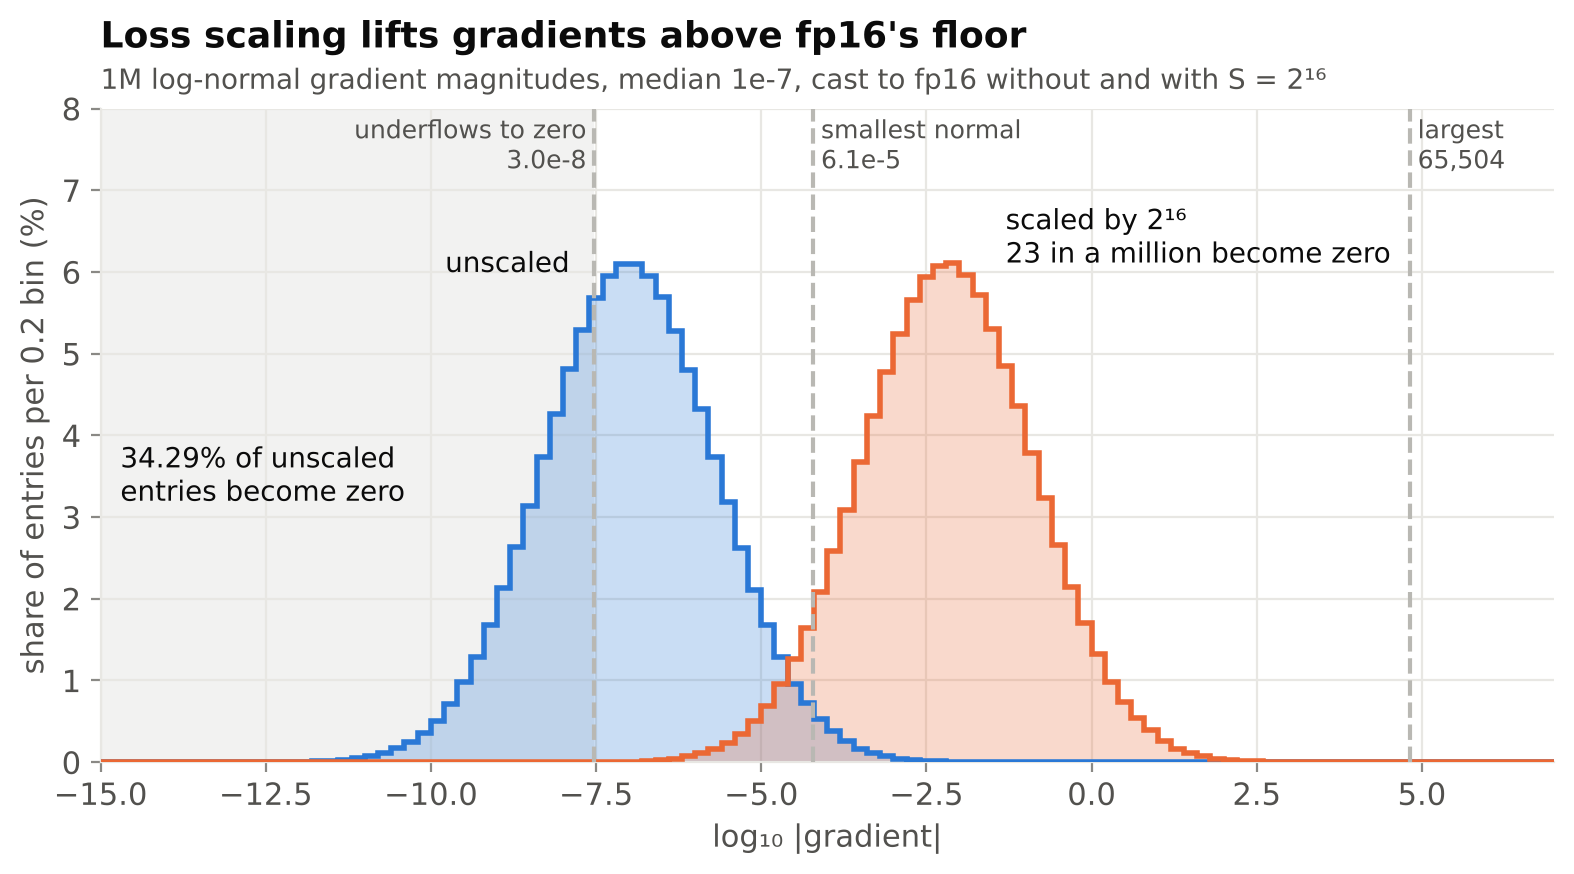

In [4]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np

    # Same seeded log-normal gradients as the article's first code block.
    rng = np.random.default_rng(0)
    g = np.exp(rng.normal(np.log(1e-7), 3.0, 1_000_000)).astype(np.float32)
    K = 16
    S = np.float32(2.0 ** K)

    zero0 = np.mean(g.astype(np.float16) == 0)
    zeroS = np.mean((g * S).astype(np.float16) == 0)
    print(f"zero unscaled {zero0:.2%}, zero at 2^{K} {zeroS:.2%}")

    underflow = np.log10(2.0 ** -25)     # round-to-nearest underflow-to-zero point, ~3.0e-8
    normal = np.log10(2.0 ** -14)    # smallest normal, 6.1e-5
    top = np.log10(65504.0)          # largest finite fp16

    x0 = np.log10(g.astype(np.float64))
    xS = x0 + K * np.log10(2.0)
    bins = np.arange(-15, 7.01, 0.2)

    f, ax = fig()
    w = np.full(g.size, 100.0 / g.size)
    for x, c in ((x0, S1), (xS, S2)):
        ax.hist(x, bins=bins, weights=w, color=c, alpha=0.25, lw=0, zorder=2)
        ax.hist(x, bins=bins, weights=w, histtype="step", color=c, lw=2, zorder=3)

    # shade the region that becomes zero, unscaled
    ax.axvspan(-15, underflow, color=NEUTRAL, alpha=0.18, lw=0, zorder=0)
    for xv, txt in ((underflow, "underflows to zero\n3.0e-8"), (normal, "smallest normal\n6.1e-5"),
                    (top, "largest\n65,504")):
        ax.axvline(xv, color=NEUTRAL, lw=1.5, ls="--", zorder=4)
        left = xv == underflow                  # label to the left so it clears the next line
        ax.text(xv - 0.12 if left else xv + 0.12, 7.9, txt, color=INK_2, fontsize=9, va="top",
                ha="right" if left else "left")

    ax.text(-7.9, 6.0, "unscaled", color=INK, fontsize=10, ha="right")
    ax.text(-1.3, 6.0, "scaled by 2¹⁶\n23 in a million become zero", color=INK, fontsize=10, ha="left", va="bottom")
    ax.text(-14.7, 3.2, "34.29% of unscaled\nentries become zero", color=INK, fontsize=10)

    ax.set_xlim(-15, 7)
    ax.set_ylim(0, 8)
    ax.set_xlabel("log₁₀ |gradient|")
    ax.set_ylabel("share of entries per 0.2 bin (%)")
    ax.set_title("Loss scaling lifts gradients above fp16's floor")
    subtitle(ax, "1M log-normal gradient magnitudes, median 1e-7, cast to fp16 without and with S = 2¹⁶")
    save(f, pathlib.Path(__file__).parent / "11-fp16-underflow.png")
import matplotlib.pyplot as plt
plt.show()